In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, TensorDataset
from tensorflow.keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


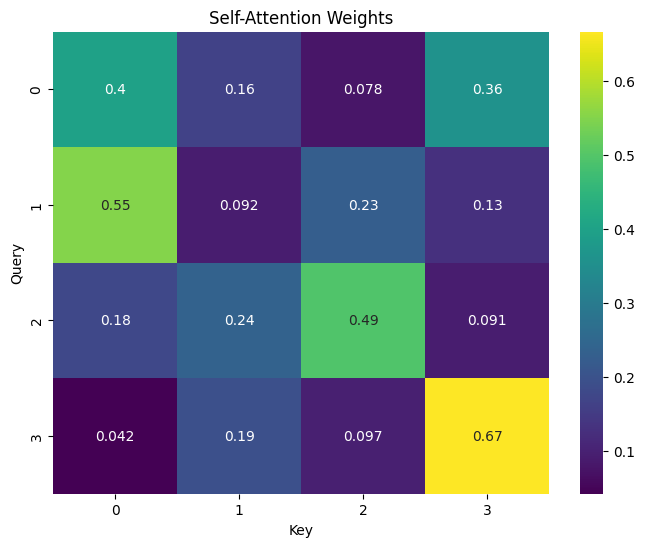

In [5]:
def self_attention(query, key, value):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / np.sqrt(d_k)
    attention_weights = torch.nn.functional.softmax(scores, dim=-1)

    output = torch.matmul(attention_weights, value)

    return output, attention_weights

sequence_length = 4
d_k = 8

query = torch.randn(1, sequence_length, d_k)
key = torch.randn(1, sequence_length, d_k)
value = torch.randn(1, sequence_length, d_k)

output, attention = self_attention(query, key, value)

plt.figure(figsize=(8, 6))
sns.heatmap(attention[0].detach().numpy(), annot=True, cmap='viridis')
plt.title('Self-Attention Weights')
plt.xlabel('Key')
plt.ylabel('Query')
plt.show()

In [6]:
model_name = 'bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.to(device)

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()
index_word = {v: k for k, v in word_index.items()}

def sequence_to_text(sequence):
    return ' '.join([index_word.get(i - 3, '') for i in sequence])
train_texts = [sequence_to_text(seq) for seq in X_train[:1000]] # Using subset for demo
train_labels = y_train[:1000]

encoded = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

train_dataset = TensorDataset(
    encoded['input_ids'],
    encoded['attention_mask'],
    torch.tensor(train_labels)
)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print("Data preparation complete. Sample sizes:")
print(f"Train texts: {len(train_texts)}")
print(f"Max sequence length: {encoded ['input_ids'].shape[1]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Data preparation complete. Sample sizes:
Train texts: 1000
Max sequence length: 128
